# 03b-04 - Bundle Adjustment

You will see how the software placed every camera and every tie point of your flight at once, then run a small adjustment yourself.

We begin with the whole flight, the sparse cloud with its cameras above it. Then we ask where each camera ended up against the receiver's position, send one photograph's points back into it, and compare the calibrated camera with the software's guess. Finally we count the block and adjust eight photographs ourselves.

This notebook reads the flight named in `data/flight.json`. Before you run anything, choose *File*, then *Save As*, and give the copy a name with `-mywork` in it, so that the next pull never collides with your work.

In [1]:
import json

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import sfm_tools as sfm

plt.style.use('default')
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 72

flight, choices = sfm.load_flight("data/flight.json")
reference = json.load(open("data/ground_truth.json"))["p03b"]
print(f"the flight {flight['label']} of {flight['date']}: {flight['aircraft']} at "
      f"{flight['altitude_agl_m']} m, {flight['n_photos']} photographs")

the flight flight-2026-09-23 of 2026-09-23: DJI Mini 3 at 79.3 m, 85 photographs


## The sparse cloud and the cameras

The cell opens the software's reconstruction and draws every point and every camera from an oblique angle.

85 photographs   reference 85
80679 points   reference 80679
369157 observations   reference 369157


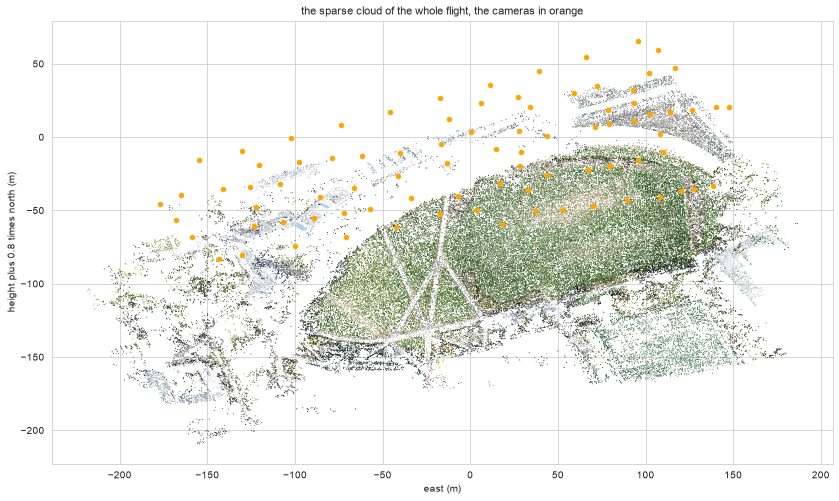

In [2]:
block = sfm.load_block("data/block.npz")
tracks = sfm.load_tracks("data/tracks.npz")
poses = zip(block["rotation"], block["translation"])
centres = np.array([sfm.camera_centre(r, t) for r, t in poses])
print(f"{len(block['names'])} photographs   reference {reference['block']['shots']}")
print(f"{len(block['points'])} points   reference {reference['block']['points']}")
print(f"{len(tracks['shot'])} observations   reference {reference['block']['observations']}")
fig, ax = plt.subplots(figsize=(14, 8))
sfm.show_cloud(ax, block["points"], rgb=block["colors"], view="oblique",
               title="the sparse cloud of the whole flight, the cameras in orange")
ax.scatter(centres[:, 0], centres[:, 2] + sfm.OBLIQUE_NORTH * centres[:, 1], s=20, color="orange")

The coloured sheet is the ground and everything on it. The orange dots above it are the cameras, one for each photograph. All of this came out of one solve. Every point is a tie point, a spot on the ground that several photographs saw. The three counts say how many photographs the software kept, how many points it placed, and how many times a point was seen. Look how the cameras hang in one flat plane while the crowns stand up out of the sheet.

## Where the cameras ended up

The cell subtracts the receiver's position from each camera's solved centre and draws the differences as arrows.

average move 0.903 m   reference 0.903
the software was told to trust the receiver to 3 m


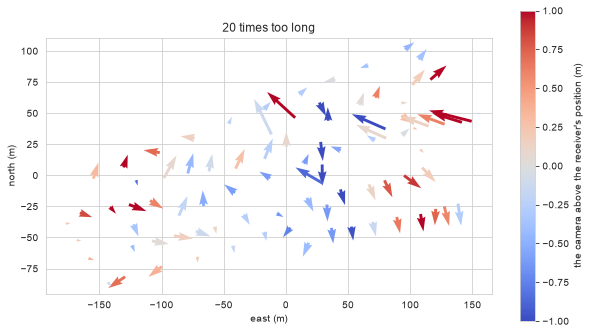

In [3]:
gps = block["gps"]
difference = centres - gps
distance = np.linalg.norm(difference, axis=1)
receiver = reference["block"]["receiver"]
print(f"average move {distance.mean():.3f} m   reference {receiver['mean_3d_m']}")
print(f"the software was told to trust the receiver to {receiver['assumed_accuracy_m']} m")
STRETCH = 20
fig, ax = plt.subplots(figsize=(10, 7))
arrows = ax.quiver(gps[:, 0], gps[:, 1], difference[:, 0], difference[:, 1], difference[:, 2],
                   angles="xy", scale_units="xy", scale=1 / STRETCH, cmap="coolwarm", clim=(-1, 1))
ax.set(aspect="equal", xlabel="east (m)", ylabel="north (m)", title=f"{STRETCH} times too long")
fig.colorbar(arrows, ax=ax, label="the camera above the receiver's position (m)", shrink=0.8)

The drone's receiver wrote a position into every file. The software treated it as a loose anchor and let the photographs decide. The arrows show how far each camera moved, lengthened so a metre shows. Their colour is the up and down part. Read the average move against the accuracy the software was told to trust. Arrows pointing every way are the receiver's noise. Arrows all pointing one way would be a shift of the whole block, which only points measured on the ground could catch.

## The collinearity equations

The cell sends every point this photograph saw back into it and compares with where the feature was found.

median residual 0.683 px   reference 0.683


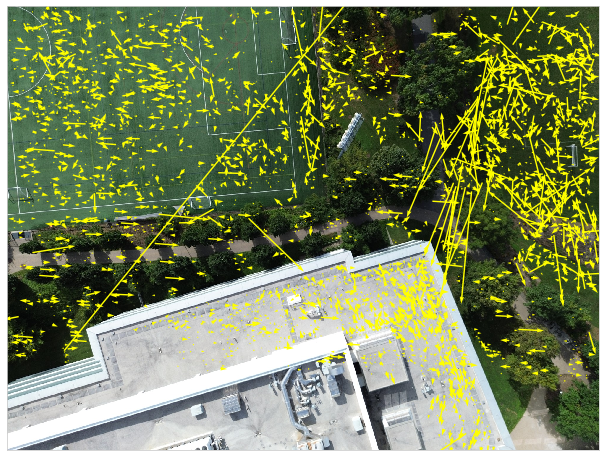

In [4]:
camera, W, H = block["camera"], block["camera"]["width"], block["camera"]["height"]
shot = choices["photos"]["a"]["shot_index"]
seen = tracks["shot"] == shot
X = block["points"][tracks["point"][seen]]
u, v, _ = sfm.project_brown(X, block["rotation"][shot], block["translation"][shot], camera, W, H)
fu, fv = sfm.feature_pixels(np.column_stack([tracks["x"], tracks["y"]])[seen], W, H)
residual = np.hypot(u - fu, v - fv)
residual_a = reference["block"]["residual_a"]
print(f"median residual {np.median(residual):.3f} px   reference {residual_a['median_px']}")
fig, ax = plt.subplots(figsize=(14, 8))
sfm.show_image(ax, sfm.read_image("data/photo_a.jpg"), extent=(0, W, H, 0))
ax.quiver(fu, fv, u - fu, v - fv, angles="xy", scale_units="xy", scale=1 / 40, color="yellow")

The lens, a ground point and its image lie on one straight line, the collinearity condition. Sending a point back through the lens says where it should appear. The gap to where the feature was found is the residual, the adjustment's leftover. A typical gap is under a pixel, so the arrows are drawn forty times too long. Look where the long arrows gather. Crowns moved in the wind. One arrow may cross the whole picture, a wrong match that slipped through. The next cell prints the equations.

In [5]:
import inspect  # the equations themselves, for those who want them
print(inspect.getsource(sfm.project_brown))

def project_brown(X, rotation, translation, camera, width, height):
    """The collinearity equations: world points into (u, v, depth) of an image of the given size.
    Each point goes into the camera's frame, through the perspective division, through the Brown
    distortion (k1, k2, k3 radial, p1, p2 decentring) and the focal length and principal point
    in normalised units, then into pixels; depth is the distance along the camera's axis."""
    X = np.atleast_2d(np.asarray(X, dtype=float))
    p = X @ rodrigues(rotation).T + np.asarray(translation, dtype=float)
    depth = p[:, 2]
    with np.errstate(divide="ignore", invalid="ignore"):
        x = p[:, 0] / depth
        y = p[:, 1] / depth
    k1 = camera.get("k1", 0.0)
    k2 = camera.get("k2", 0.0)
    k3 = camera.get("k3", 0.0)
    p1 = camera.get("p1", 0.0)
    p2 = camera.get("p2", 0.0)
    r2 = x * x + y * y
    radial = 1.0 + k1 * r2 + k2 * r2 ** 2 + k3 * r2 ** 3
    xd = x * radial + 2.0 * p1 * x * y + p2 * (r2 + 2.0 * 

## The camera the flight calibrated

The cell compares the focal length the flight solved for with the software's guess, then projects the same points through that guess.

focal length 2548.7 px, the guess 2666.7 px   reference 2548.7 and 2666.7
median residual through the guess 42.6 px   reference 42.6


[Text(0.5, 0, 'distance from the centre of the frame (px)'),
 Text(0, 0.5, "the lens's shift (px)")]

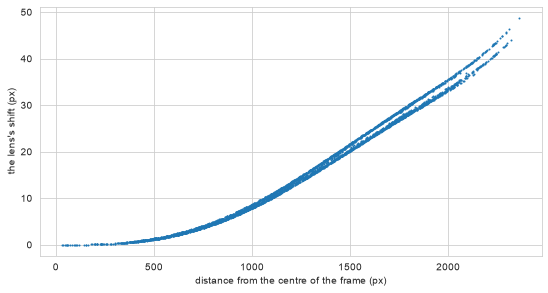

In [6]:
prior = block["camera_prior"]
calibration = reference["block"]["calibration"]
print(f"focal length {camera['focal_x'] * W:.1f} px, the guess {prior['focal_x'] * W:.1f} px   "
      f"reference {calibration['focal_px']} and {calibration['focal_prior_px']}")
u2, v2, _ = sfm.project_brown(X, block["rotation"][shot], block["translation"][shot], prior, W, H)
print(f"median residual through the guess {np.median(np.hypot(u2 - fu, v2 - fv)):.1f} px   "
      f"reference {residual_a['with_prior_camera_median_px']}")
pinhole = dict(camera, k1=0, k2=0, k3=0, p1=0, p2=0)  # the same camera without its distortion
u3, v3, _ = sfm.project_brown(X, block["rotation"][shot], block["translation"][shot], pinhole, W, H)
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(np.hypot(u3 - W / 2, v3 - H / 2), np.hypot(u - u3, v - v3), ".", markersize=2)
ax.set(xlabel="distance from the centre of the frame (px)", ylabel="the lens's shift (px)")

The software started from a guessed camera and solved for the real one. Read the two focal lengths against each other. The guess came from a number in the files, and the other guess of 03b-01 was larger still. Through the guessed camera the same points miss their features by tens of pixels. Calibration was not optional. Each dot of the curve is one point this photograph saw. It shows how far the lens pushes a point outwards, more and more towards the corner.

## The block counted, and eight photographs adjusted

The cell counts unknowns against equations for the whole block, then spoils eight cameras on purpose and lets the solver bring them back.

redundancy 495759   reference 495759


residual 14.44 px spoiled, 0.849 px solved   reference 14.44 and 0.849
the cameras came back to within 0.152 m   reference 0.152


[Text(0.5, 0, 'residual (px)'),
 Text(0, 0.5, 'observations'),
 Text(0.5, 1.0, 'blue spoiled, orange solved')]

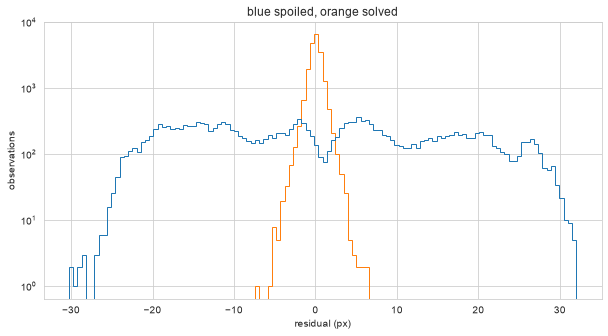

In [7]:
unknowns = 6 * len(block["names"]) + 3 * len(block["points"]) + 8  # and eight for the lens
equations = 2 * len(tracks["shot"])
print(f"redundancy {equations - unknowns}   reference {reference['block']['redundancy']}")
result = sfm.mini_bundle(block, tracks, [block["names"].index(name) for name in choices["group"]])
bundle = reference["block"]["mini_bundle"]
print(f"residual {result['rms_perturbed_px']} px spoiled, {result['rms_solved_px']} px solved   "
      f"reference {bundle['rms_perturbed_px']} and {bundle['rms_solved_px']}")
print(f"the cameras came back to within {result['centre_recovery_median_m']} m   "
      f"reference {bundle['centre_recovery_median_m']}")
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist([result["before"], result["after"]], bins=120, log=True, histtype="step")
ax.set(xlabel="residual (px)", ylabel="observations", title="blue spoiled, orange solved")

A camera has six unknowns, its position and its turn. A point has three. Every observation gives two equations. The block has several equations for every unknown, and that surplus is the redundancy. It is what the word adjustment means. No solution fits every equation, so the solver picks the one with the smallest leftovers. We spoil the eight cameras by a fraction of a degree and half a metre. The typical residual falls from many pixels to under one. The cameras return to within a few centimetres.

## Your turn

The software solved for the focal length on the flight. Hold it at the software's guess instead and solve the same eight photographs again, starting from the software's own poses without spoiling them. Read the residual after the solve and how far the cameras moved in height. Run the cell as it is, then change the marked value and run it again.

The residual barely changed, so where did the wrong focal length go? Write your answer in one or two sentences. The answer comes in Friday's post, not in the kit.

In [8]:
FOCAL = "calibrated"  # change me: "prior"
focal = None if FOCAL == "calibrated" else block["camera_prior"]["focal_x"]
group = [block["names"].index(name) for name in choices["group"]]
again = sfm.mini_bundle(block, tracks, group, focal=focal, perturb=0)
print(f"the lens held at {again['focal'] * W:.1f} px")
print(f"residual {again['rms_solved_px']} px after the solve, against the software's own "
      f"{again['rms_software_px']} px")
print(f"the cameras moved {again['height_shift_median_m']:+.3f} m in height, the median of eight")

the lens held at 2548.7 px
residual 0.849 px after the solve, against the software's own 0.987 px
the cameras moved -0.012 m in height, the median of eight


## Check your understanding

1. The lens, a ground point and its image lie on one line. Which six numbers fix where a photograph was taken and how it was turned?
2. The arrows from the receiver to the software's cameras point every way. What would arrows all pointing one way mean, and what could catch that?
3. Every photograph looked nearly straight down. Why can such a block not tell a longer focal length from a greater flying height, and what breaks the tie?
4. The block has several equations for every unknown. Name two things that surplus buys which a block with barely enough equations would not have.

## Where we are

You have read the software's reconstruction, checked its cameras against the receiver, sent a photograph's points back into it and read the residuals, compared the calibrated camera with the guess, and run an adjustment that brought spoiled cameras back. You now know that a block has far more equations than unknowns, that the residuals are its honesty, and that a block of photographs looking straight down can hide a wrong focal length in the flying height. In 03b-05 we find a height for nearly every pixel.

## Further resources

Nothing in this course requires anything below.

- Elements of Photogrammetry with Applications in GIS, Wolf, Dewitt and Wilkinson, McGraw-Hill, 2014, chapter 17 on the bundle adjustment and self-calibration
- Structure-from-Motion Revisited, Schönberger and Frahm, 2016: https://openaccess.thecvf.com/content_cvpr_2016/papers/Schonberger_Structure-From-Motion_Revisited_CVPR_2016_paper.pdf
- Mitigating systematic error in topographic models derived from UAV and ground-based image networks, James and Robson, 2014: https://onlinelibrary.wiley.com/doi/10.1002/esp.3609
- Large-scale bundle adjustment in SciPy, the SciPy Cookbook, 2016: https://scipy-cookbook.readthedocs.io/items/bundle_adjustment.html

The photographs, the software's files and the products are the course's own flight, published under CC BY 4.0.